## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
from panns_inference import AudioTagging


## Dataset Root

In [2]:
data_root = "/home/cjk/Dev/cats"
labels = sorted(os.listdir(data_root))  # Angry, Defence, Fighting, Happy, ...
print(labels)


['Angry', 'Defence', 'Fighting', 'Happy', 'HuntingMind', 'Mating', 'MotherCall', 'Paining', 'Resting', 'Warning']


## Load Model

In [3]:
model = AudioTagging(checkpoint_path=None, device='cuda')

Checkpoint path: /home/cjk/panns_data/Cnn14_mAP=0.431.pth
GPU number: 1


## Loop Over Audio Files

In [4]:
features = []
processed_files = []
file_labels = []

for label in labels:
    folder = os.path.join(data_root, label)
    mp3_files = [f for f in os.listdir(folder) if f.endswith(".mp3")]
    print(f"{label}: {len(mp3_files)} files")

    for filename in mp3_files:
        path = os.path.join(folder, filename)
        audio, sr = librosa.load(path, sr=32000, mono=True)
        audio = audio[None, :]
        _, embedding = model.inference(audio)

        features.append(embedding[0])
        processed_files.append(filename)
        file_labels.append(label)

X = np.vstack(features)
y = np.array(file_labels)
print(X.shape, y.shape)


Angry: 300 files
Defence: 291 files
Fighting: 299 files
Happy: 295 files
HuntingMind: 289 files
Mating: 300 files
MotherCall: 296 files
Paining: 287 files
Resting: 296 files
(2953, 2048) (2953,)


## Load Result as DF

In [5]:
df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df.insert(0, "label", y)
df.insert(0, "filename", processed_files)
df


,filename,label,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_2038,feat_2039,feat_2040,feat_2041,feat_2042,feat_2043,feat_2044,feat_2045,feat_2046,feat_2047
0,car_extcoll0177.mp3,Angry,0.0,0.000000,0.0,0.0,0.0,0.960603,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.130637,0.000000,0.000000,0.0
1,YashLL_Cat0274Ang.mp3,Angry,0.0,1.845587,0.0,0.0,0.0,0.529180,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.063494,0.000000,0.084741,0.0
2,LastEntry_cat1265Ang.mp3,Angry,0.0,0.000000,0.0,0.0,0.0,0.640453,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.292330,0.201758,0.799784,0.0
3,cat_flickr01407.mp3,Angry,0.0,1.151690,0.0,0.0,0.0,0.972877,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.098907,0.0
4,Cat_angry1021.mp3,Angry,0.0,0.381891,0.0,0.0,0.0,0.768269,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.109228,0.000000,0.439132,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2948,Online_Cat0469Grl.mp3,Warning,0.0,1.762939,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.473790,0.000000,0.208251,0.0
2949,Last_addCat330Grl.mp3,Warning,0.0,1.962018,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.600422,0.000000,0.000000,0.0
2950,car_extcoll0185.mp3,Warning,0.0,0.283605,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.558773,0.000000,0.348263,0.0
2951,cat_flickr01350.mp3,Warning,0.0,1.267387,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.017576,0.000000,0.381450,0.0


## PCA to 2D

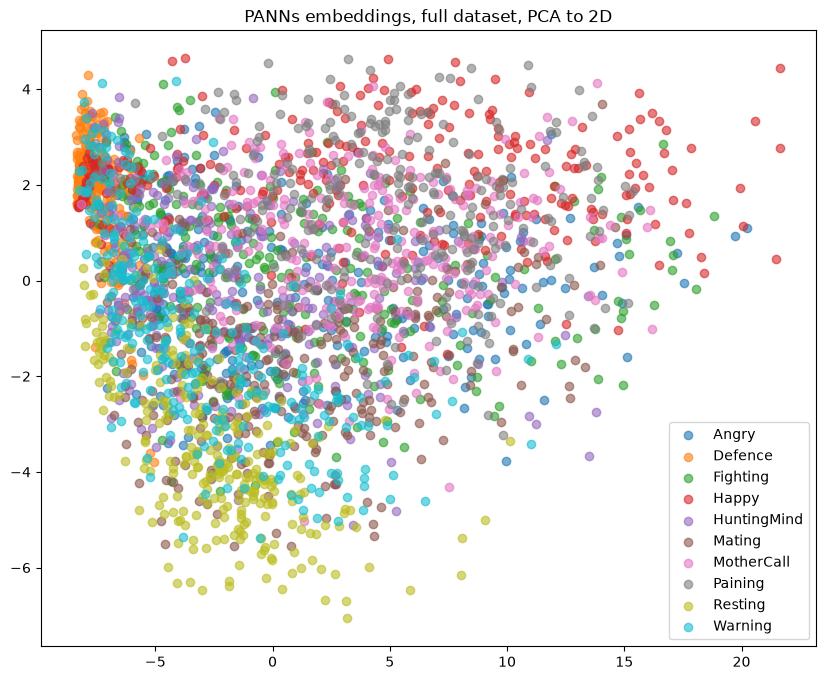

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_2d = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 8))
for label in labels:
    mask = y == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, alpha=0.6)
plt.legend()
plt.title("PANNs embeddings, full dataset, PCA to 2D")
plt.show()


## PCA to 3D

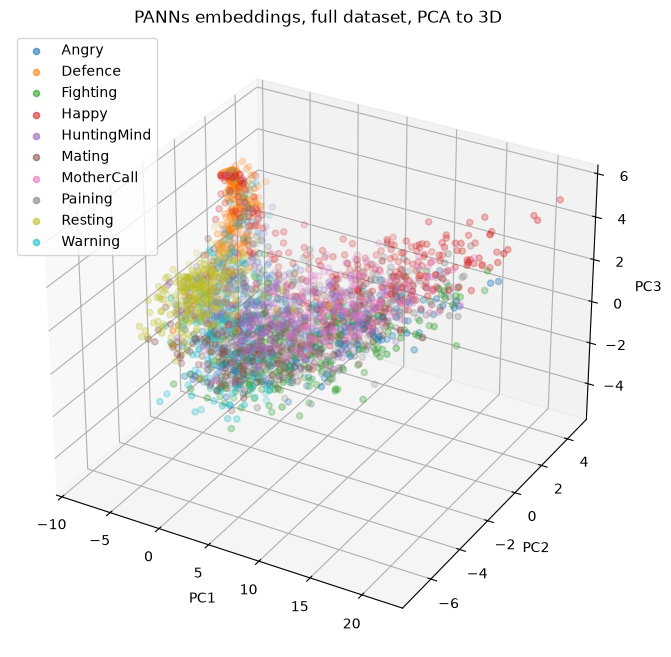

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_3d = PCA(n_components=3).fit_transform(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

for label in labels:
    mask = y == label
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2], label=label, alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.title("PANNs embeddings, full dataset, PCA to 3D")
plt.show()


## UMAP

/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


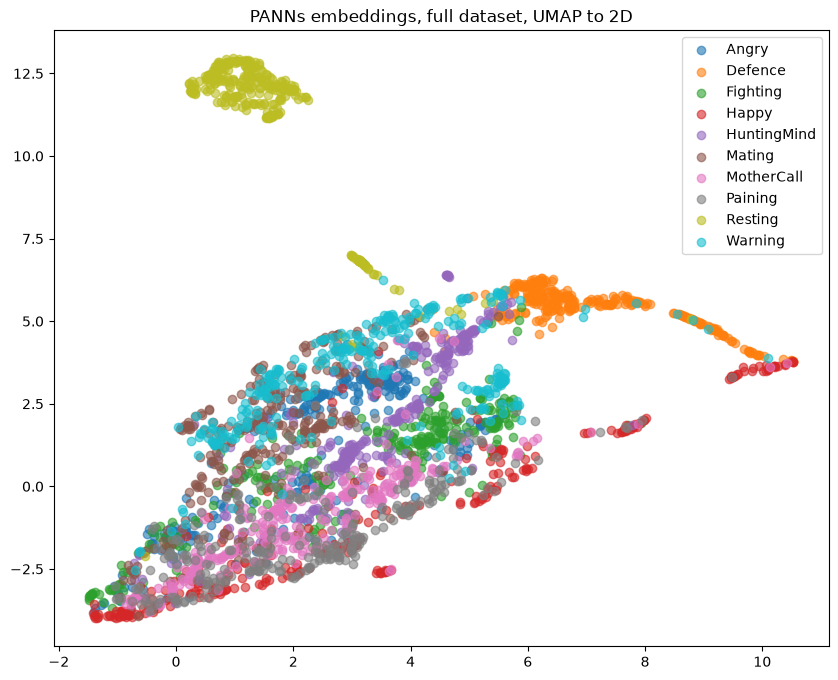

In [10]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(10, 8))
for label in labels:
    mask = y == label
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], label=label, alpha=0.6)
plt.legend()
plt.title("PANNs embeddings, full dataset, UMAP to 2D")
plt.show()


## Original Paper Metrics

#### Table 2 — best classifier performance (3x_Aug dataset, FDAP features):

| Classifier | Accuracy CNN | Accuracy CDBN | F1 CNN | F1 CDBN | AUC CNN | AUC CDBN |
|---|---|---|---|---|---|---|
| RF | 84.64% | 86.32% | 0.85 | 0.86 | 0.988 | 0.988 |
| KNN | 81.60% | 80.32% | 0.82 | 0.80 | 0.898 | 0.890 |
| Extra Trees | 83.80% | 84.29% | 0.84 | 0.84 | 0.987 | 0.985 |
| LDA | 78.48% | 81.84% | 0.78 | 0.82 | 0.975 | 0.979 |
| SVM | 87.43% | 90.88% | 0.87 | 0.91 | 0.992 | 0.994 |
| Ensemble | 90.80% | 91.13% | 0.91 | 0.91 | 0.994 | 0.995 |



#### Table 3 — Ensemble classifier across augmentation/pooling settings:

| Dataset | Accuracy CNN | Accuracy CDBN | F1 CNN | F1 CDBN | AUC CNN | AUC CDBN |
|---|---|---|---|---|---|---|
| Original_GAP | 70.71% | 76.09% | 0.690 | 0.760 | 0.958 | 0.963 |
| Original_FDAP | 79.12% | 82.15% | 0.780 | 0.820 | 0.974 | 0.982 |
| 1x_Aug_GAP | 80.61% | 76.39% | 0.810 | 0.760 | 0.977 | 0.970 |
| 1x_Aug_FDAP | 86.51% | 87.52% | 0.860 | 0.880 | 0.989 | 0.989 |
| 2x_Aug_GAP | 81.89% | 76.60% | 0.820 | 0.760 | 0.982 | 0.969 |
| 2x_Aug_FDAP | 89.31% | 87.96% | 0.890 | 0.880 | 0.993 | 0.991 |
| 3x_Aug_GAP | 83.04% | 79.49% | 0.830 | 0.790 | 0.985 | 0.977 |
| 3x_Aug_FDAP | 90.80% | 91.13% | 0.910 | 0.910 | 0.994 | 0.995 |




## SVM with RBF (compared to the original paper)

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# drop dead (zero-variance) dimensions before fitting — free, no information lost
X_live = X[:, X.var(axis=0) > 0]

le = LabelEncoder()
y_enc = le.fit_transform(y)

clf = SVC(kernel="rbf", probability=True)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(
    clf, X_live, y_enc, cv=cv,
    scoring=["accuracy", "f1_macro", "roc_auc_ovr"],
)

print(f"Accuracy: {scores['test_accuracy'].mean():.4f} (±{scores['test_accuracy'].std():.4f})")
print(f"F1 (macro): {scores['test_f1_macro'].mean():.4f}")
print(f"AUC (one-vs-rest): {scores['test_roc_auc_ovr'].mean():.4f}")


/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packa

Accuracy: 0.8175 (±0.0108)
F1 (macro): 0.8155
AUC (one-vs-rest): 0.9814


## Random Forest (compared to the original paper)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_scores = cross_validate(
    rf_clf, X_live, y_enc, cv=cv,
    scoring=["accuracy", "f1_macro", "roc_auc_ovr"],
)

print(f"Accuracy: {rf_scores['test_accuracy'].mean():.4f} (±{rf_scores['test_accuracy'].std():.4f})")
print(f"F1 (macro): {rf_scores['test_f1_macro'].mean():.4f}")
print(f"AUC (one-vs-rest): {rf_scores['test_roc_auc_ovr'].mean():.4f}")


Accuracy: 0.8374 (±0.0198)
F1 (macro): 0.8363
AUC (one-vs-rest): 0.9837


## Ensemble SVM + RF (compared to original paper)

In [15]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
voting_clf = VotingClassifier(
    estimators=[
        ("svm", SVC(kernel="rbf", probability=True)),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ],
    voting="soft",
)

voting_scores = cross_validate(
    voting_clf, X_live, y_enc, cv=cv,
    scoring=["accuracy", "f1_macro", "roc_auc_ovr"],
)

print(f"Accuracy: {voting_scores['test_accuracy'].mean():.4f} (±{voting_scores['test_accuracy'].std():.4f})")
print(f"F1 (macro): {voting_scores['test_f1_macro'].mean():.4f}")
print(f"AUC (one-vs-rest): {voting_scores['test_roc_auc_ovr'].mean():.4f}")


/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packa

Accuracy: 0.8331 (±0.0099)
F1 (macro): 0.8322
AUC (one-vs-rest): 0.9809


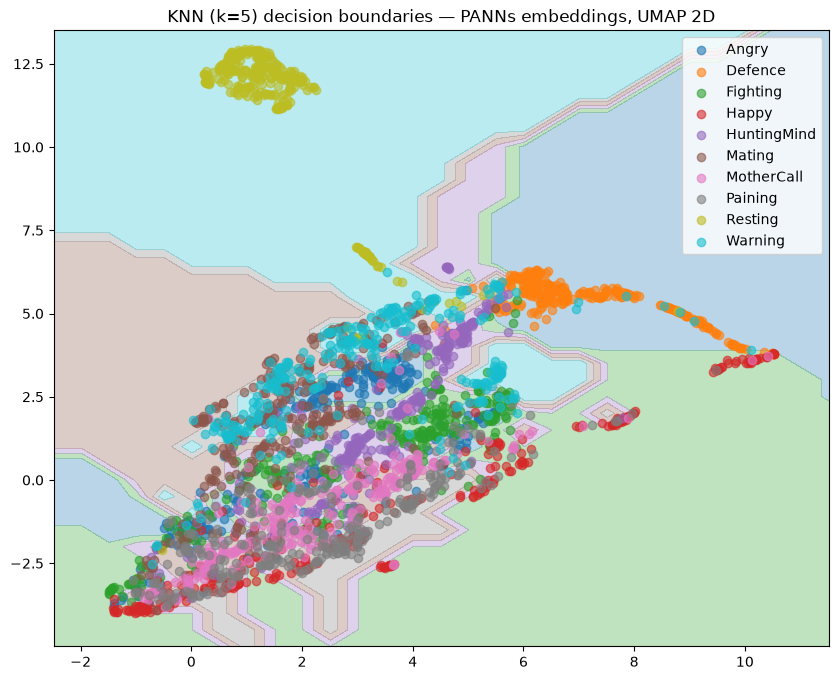

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_umap, y)

h = 0.5
x_min, x_max = X_umap[:, 0].min() - 1, X_umap[:, 0].max() + 1
y_min, y_max = X_umap[:, 1].min() - 1, X_umap[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

class_to_int = {label: i for i, label in enumerate(labels)}
Z_pred = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.array([class_to_int[z] for z in Z_pred]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.tab10)

for label in labels:
    mask = y == label
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], label=label, alpha=0.6)

plt.legend()
plt.title(f"KNN (k={knn.n_neighbors}) decision boundaries — PANNs embeddings, UMAP 2D")
plt.show()
